In [53]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats


In [54]:
mean = 0 
std = 1
N = [100, 500, 1000]
sample_array = []

### 1.1 Сгенерировать выборки объема N (N = 100, 500, 1000) из нормальногораспределения с одинаковыми параметрами. Параметры задать самостоятельно. 

In [55]:
for n in N:
    sample = np.random.normal(mean, std, n)
    sample_array.append(sample)

### 1.2 Построить квантильные графики и гистограммы для построенных выборок.

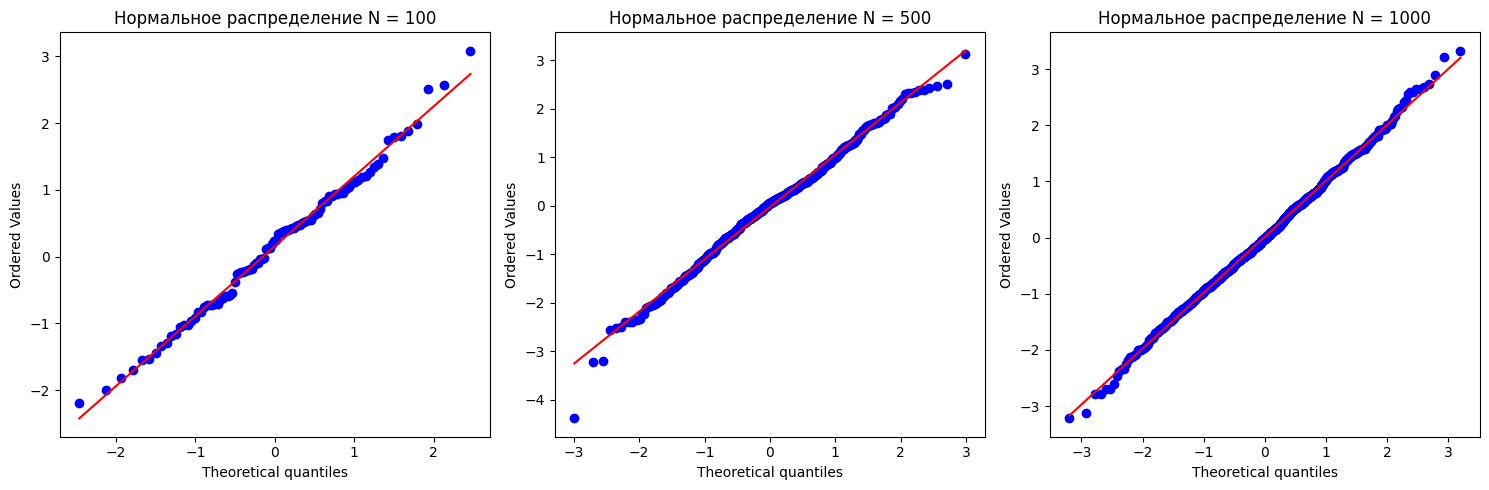

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

stats.probplot(sample_array[0], dist="norm", plot=axes[0])
axes[0].set_title("Нормальное распределение N = 100")

stats.probplot(sample_array[1], dist="norm", plot=axes[1])
axes[1].set_title("Нормальное распределение N = 500")

stats.probplot(sample_array[2], dist="norm", plot=axes[2])
axes[2].set_title("Нормальное распределение N = 1000")

plt.tight_layout()
plt.show()

### 1.3 Найти оценки числовых характеристик (выборочные среднее, дисперсию, СКО).

In [ ]:
mean_100 = np.mean(sample_array[0])
variance_100  = np.var(sample_array[0], ddof = 1) # ddof = 1 для несмещённости оценки
std_dev_100 = np.std(sample_array[0], ddof=1)

print('Для выборки размера N = 100: ')
print(f"Выборочное среднее: {mean_100:.2f}")
print(f"Выборочная дисперсия: {variance_100:.2f}")
print(f"Выборочное СКО: {std_dev_100:.2f}\n")


mean_500= np.mean(sample_array[1])
variance_500  = np.var(sample_array[1], ddof = 1) 
std_dev_500 = np.std(sample_array[1], ddof=1)

print('Для выборки размера N = 500: ')
print(f"Выборочное среднее: {mean_500:.2f}")
print(f"Выборочная дисперсия: {variance_500:.2f}")
print(f"Выборочное СКО: {std_dev_500:.2f}\n")

mean_1000= np.mean(sample_array[2])
variance_1000  = np.var(sample_array[2], ddof = 1)
std_dev_1000 = np.std(sample_array[2], ddof=1)

print('Для выборки размера N = 1000: ')
print(f"Выборочное среднее: {mean_1000:.2f}")
print(f"Выборочная дисперсия: {variance_1000:.2f}")
print(f"Выборочное СКО: {std_dev_1000:.2f}\n")

    

Для выборки размера N = 100: 
Выборочное среднее: 0.16
Выборочная дисперсия: 1.07
Выборочное СКО: 1.04

Для выборки размера N = 500: 
Выборочное среднее: -0.02
Выборочная дисперсия: 1.16
Выборочное СКО: 1.08

Для выборки размера N = 1000: 
Выборочное среднее: 0.02
Выборочная дисперсия: 0.99
Выборочное СКО: 0.99



### 1.4 Построить доверительные интервалы для математического ожидания при известном значении дисперсии на уровне значимости α = 0,05.

In [58]:
sigma = (variance_100) ** 0.5
alpha = 0.05
n = len(sample_array[0])

# Выборочное среднее
x_bar = mean_100

# Квантиль нормального распределения
z_alpha_2 = stats.norm.ppf(1 - alpha / 2)

# Стандартная ошибка среднего
se = sigma / (n ** 0.5)

lower_bound = x_bar - z_alpha_2 * se
upper_bound = x_bar + z_alpha_2 * se

print(f"Доверительный интервал при известной дисперсии для N = 100: [{lower_bound:.2f}, {upper_bound:.2f}]")

Доверительный интервал при известной дисперсии для N = 100: [-0.05, 0.36]


In [59]:
sigma = (variance_500) ** 0.5
alpha = 0.05
n = len(sample_array[1])

x_bar = mean_500

z_alpha_2 = stats.norm.ppf(1 - alpha / 2)

se = sigma / (n ** 0.5)

lower_bound = x_bar - z_alpha_2 * se
upper_bound = x_bar + z_alpha_2 * se

print(f"Доверительный интервал при известной дисперсии для N = 500: [{lower_bound:.2f}, {upper_bound:.2f}]")

Доверительный интервал при известной дисперсии для N = 500: [-0.12, 0.07]


In [60]:
sigma = (variance_1000) ** 0.5
alpha = 0.05
n = len(sample_array[2])

x_bar = mean_1000

z_alpha_2 = stats.norm.ppf(1 - alpha / 2)

se = sigma / (n ** 0.5)

lower_bound = x_bar - z_alpha_2 * se
upper_bound = x_bar + z_alpha_2 * se

print(f"Доверительный интервал при известной дисперсии для N = 1000: [{lower_bound:.2f}, {upper_bound:.2f}]")

Доверительный интервал при известной дисперсии для N = 1000: [-0.05, 0.08]


### 1.5 Построить доверительные интервалы для математического ожидания при неизвестном значении дисперсии (оцененном по выборке) на уровне значимости α = 0,05.

In [61]:
means = []
left_bounds = []
right_bounds = []

alpha = 0.05
n = len(sample_array[0])

# Выборочное среднее
x_bar = mean_100

# Выборочное стандартное отклонение (несмещённая оценка)
s = variance_100

# Квантиль t-распределения
t_alpha_2 = stats.t.ppf(1 - alpha / 2, df = n - 1)

# Стандартная ошибка среднего
se = sigma / (n ** 0.5)

lower_bound = x_bar - t_alpha_2 * se
upper_bound = x_bar + t_alpha_2 * se

means.append(x_bar)
left_bounds.append(lower_bound)
right_bounds.append(upper_bound)

print(f"Доверительный интервал при неизвестной дисперсии N = 100: [{lower_bound:.2f}, {upper_bound:.2f}]")

Доверительный интервал при неизвестной дисперсии N = 100: [-0.04, 0.35]


In [62]:
alpha = 0.05
n = len(sample_array[1])

x_bar = mean_500

s = variance_500

t_alpha_2 = stats.t.ppf(1 - alpha / 2, df = n - 1)

se = sigma / (n ** 0.5)

lower_bound = x_bar - t_alpha_2 * se
upper_bound = x_bar + t_alpha_2 * se

means.append(x_bar)
left_bounds.append(lower_bound)
right_bounds.append(upper_bound)

print(f"Доверительный интервал при неизвестной дисперсии N = 500: [{lower_bound:.2f}, {upper_bound:.2f}]")

Доверительный интервал при неизвестной дисперсии N = 500: [-0.11, 0.06]


In [ ]:
alpha = 0.05
n = len(sample_array[2])

x_bar = mean_1000

s = variance_1000

t_alpha_2 = stats.t.ppf(1 - alpha / 2, df = n - 1)

se = sigma / (n ** 0.5)

lower_bound = x_bar - t_alpha_2 * se
upper_bound = x_bar + t_alpha_2 * se

means.append(x_bar)
left_bounds.append(lower_bound)
right_bounds.append(upper_bound)

print(f"Доверительный интервал при неизвестной дисперсии N = 1000: [{lower_bound:.2f}, {upper_bound:.2f}]")

Доверительный интервал при неизвестной дисперсии N = 1000: [-0.05, 0.08]


### 1.6 Построить график зависимости точечных оценок математического ожидания, а также левых и правых границ доверительных интервалов от объема выборки (на одном рисунке).

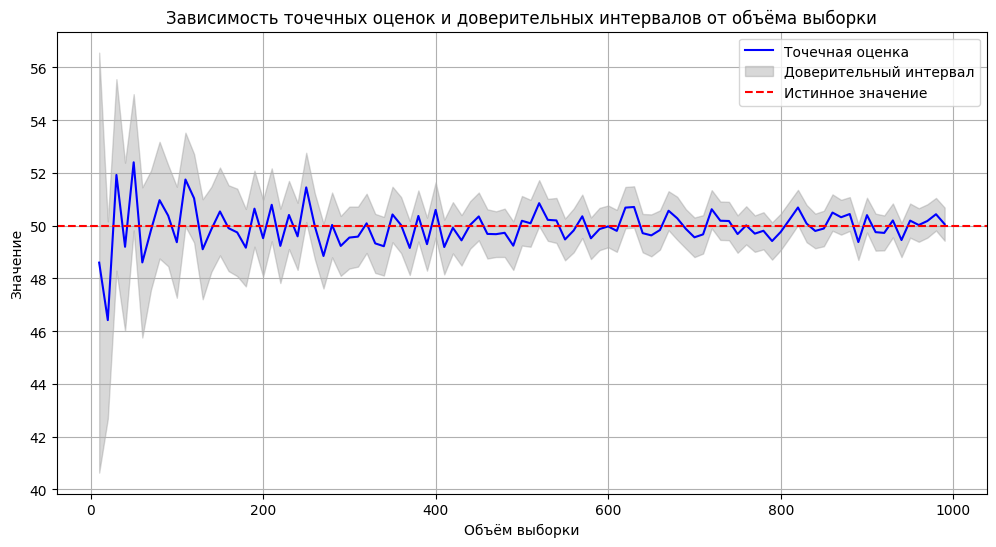

In [68]:
true_mean = 50   # истинное математическое ожидание
true_std = 10    # стандартное отклонение
sample_sizes = np.arange(10, 1000, 10)  
confidence_level = 0.95 

means = []
left_ci = []
right_ci = []

for n in sample_sizes:
    sample = np.random.normal(true_mean, true_std, n)
    sample_mean = np.mean(sample)
    se = stats.sem(sample)
    ci = stats.t.interval(confidence_level, n-1, loc=sample_mean, scale=se)
    means.append(sample_mean)
    left_ci.append(ci[0])
    right_ci.append(ci[1])

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(sample_sizes, means, label='Точечная оценка', color='blue')
plt.fill_between(sample_sizes, left_ci, right_ci, color='gray', alpha=0.3, label='Доверительный интервал')
plt.axhline(true_mean, color='red', linestyle='--', label='Истинное значение')
plt.xlabel('Объём выборки')
plt.ylabel('Значение')
plt.title('Зависимость точечных оценок и доверительных интервалов от объёма выборки')
plt.legend()
plt.grid(True)
plt.show()